In [ ]:
import os, random, numpy as np
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", DEVICE)

Using cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/final_datasets_for_cnn_224/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

In [ ]:
from google.colab import files
files.upload()

Saving dataset_split.zip to dataset_split.zip


In [ ]:
!unzip dataset_split.zip -d /content/

Archive:  dataset_split.zip
replace /content/dataset_split/test/Healthy/{DSC00452.JPG}[251].jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
split_dir  = "/content/dataset_split"
splits = ["train", "val", "test"]
ratios = {"train": 0.7, "val": 0.15, "test": 0.15}

os.makedirs(split_dir, exist_ok=True)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(split_dir, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(split_dir, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(split_dir, "test"),
    transform=transform
)

batch_size = 64

trainloader = DataLoader(train_dataset, batch_size=batch_size,
                         shuffle=True, num_workers=0, pin_memory=True)
valloader   = DataLoader(val_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0, pin_memory=True)
testloader  = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0, pin_memory=True)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset),
      "Val:", len(val_dataset),
      "Test:", len(test_dataset))


Classes: ['Healthy', 'MLB', 'Soil']
Train: 8088 Val: 1732 Test: 1736


In [ ]:
images, labels = next(iter(trainloader))
print(images.shape, labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64])


### Custom CNN  




In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (3 → 32)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32 → 64)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)   # downsampling

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (64 → 128)
        self.bn3 = nn.BatchNorm2d(128)

        self.gap = nn.AdaptiveAvgPool2d((4,4))
        self.fc1 = nn.Linear(2048, 256) # adjust if input ≠ 64x64
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32 → 16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16 → 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8 → 4
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
model = SmallCNN().to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=5)

In [ ]:
epochs = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(valloader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% "
          f"| Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    # Adjust learning rate
    scheduler.step(val_loss)

    # Early stopping
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered 🚦")
        break

print("Training Finished ✅")

Epoch 1 | Train Loss: 0.3958, Acc: 83.95% | Val Loss: 0.1855, Acc: 93.76%
Epoch 2 | Train Loss: 0.2362, Acc: 90.75% | Val Loss: 0.1757, Acc: 93.71%
Epoch 3 | Train Loss: 0.2000, Acc: 92.46% | Val Loss: 0.1698, Acc: 93.36%
Epoch 4 | Train Loss: 0.1902, Acc: 92.31% | Val Loss: 0.1354, Acc: 95.21%
Epoch 5 | Train Loss: 0.1783, Acc: 93.16% | Val Loss: 0.1396, Acc: 94.57%
Epoch 6 | Train Loss: 0.1665, Acc: 93.42% | Val Loss: 0.1311, Acc: 94.86%
Epoch 7 | Train Loss: 0.1482, Acc: 94.26% | Val Loss: 0.1303, Acc: 94.57%
Epoch 8 | Train Loss: 0.1530, Acc: 93.98% | Val Loss: 0.1140, Acc: 95.84%
Epoch 9 | Train Loss: 0.1424, Acc: 94.42% | Val Loss: 0.1486, Acc: 93.71%
Epoch 10 | Train Loss: 0.1344, Acc: 94.71% | Val Loss: 0.1084, Acc: 96.02%
Epoch 11 | Train Loss: 0.1398, Acc: 94.37% | Val Loss: 0.1089, Acc: 95.50%
Epoch 12 | Train Loss: 0.1246, Acc: 95.12% | Val Loss: 0.1031, Acc: 95.84%
Epoch 13 | Train Loss: 0.1228, Acc: 95.41% | Val Loss: 0.0914, Acc: 96.19%
Epoch 14 | Train Loss: 0.1359, Acc

In [ ]:
save_path = "/content/drive/MyDrive/TransferLearning/smallcnn_frozen_2.pth"
torch.save(model.state_dict(), save_path)
print("saved at:", save_path)

saved at: /content/drive/MyDrive/TransferLearning/smallcnn_frozen_2.pth


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SmallCNN(num_classes=3)
model.load_state_dict(torch.load("/content/drive/MyDrive/TransferLearning/smallcnn_frozen_2.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

In [ ]:
results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs,
}

torch.save(results, "/content/drive/MyDrive/TransferLearning/smallcnn_training_results.pth")
print("Saved training results ✓")

Saved training results ✓


In [ ]:
results = torch.load("/content/drive/MyDrive/TransferLearning/smallcnn_training_results.pth", map_location=DEVICE)

train_losses = results["train_losses"]
val_losses = results["val_losses"]
train_accs = results["train_accs"]
val_accs = results["val_accs"]

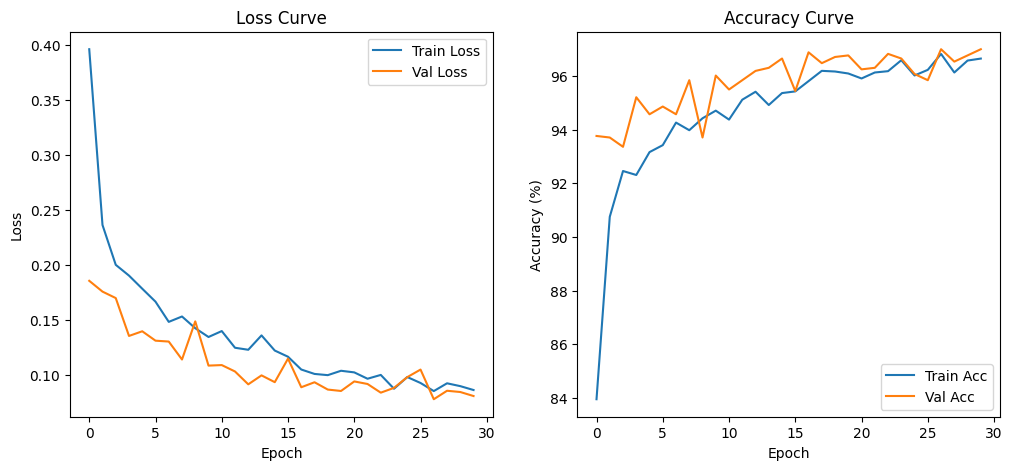

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.06%


In [ ]:
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
torch.save(eval_results, "/content/drive/MyDrive/TransferLearning/smallcnn_eval_results.pth")
print("Saved evaluation results ✓")

Saved evaluation results ✓


In [ ]:
eval_results = torch.load(
    "/content/drive/MyDrive/TransferLearning/smallcnn_eval_results.pth",
    weights_only=False
)

preds = eval_results["preds"]
labels = eval_results["labels"]
probs = eval_results["probs"]
cm = eval_results["confusion_matrix"]
report = eval_results["classification_report"]
acc = eval_results["accuracy"]

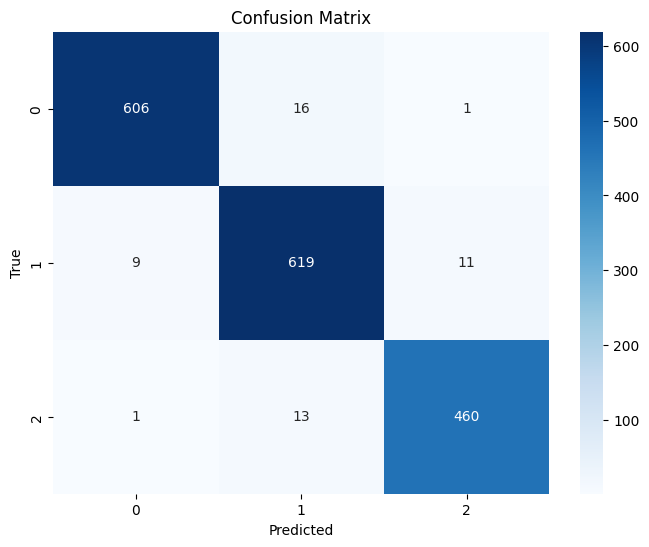

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.98      0.97      0.98       623
           1       0.96      0.97      0.96       639
           2       0.97      0.97      0.97       474

    accuracy                           0.97      1736
   macro avg       0.97      0.97      0.97      1736
weighted avg       0.97      0.97      0.97      1736



In [ ]:
cm = confusion_matrix(all_labels, all_preds)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracy):
    print(f"Class {i} Accuracy: {acc*100:.2f}%")


Class 0 Accuracy: 97.27%
Class 1 Accuracy: 96.87%
Class 2 Accuracy: 97.05%


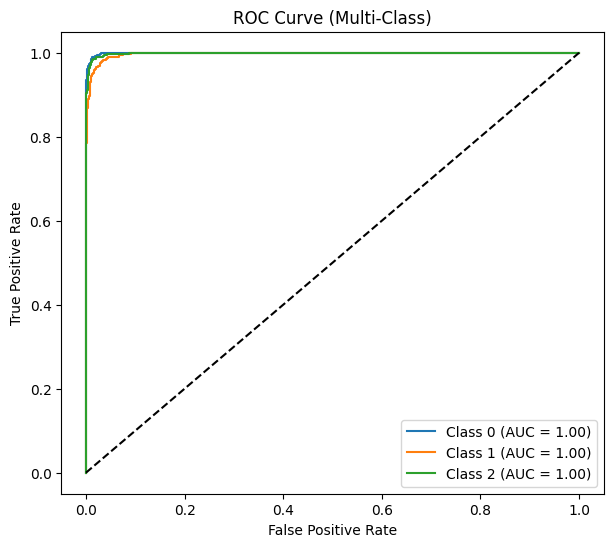

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

all_labels_bin = label_binarize(all_labels, classes=list(range(len(cm))))

plt.figure(figsize=(7,6))

for i in range(len(cm)):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], [p[i] for p in all_probs])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()

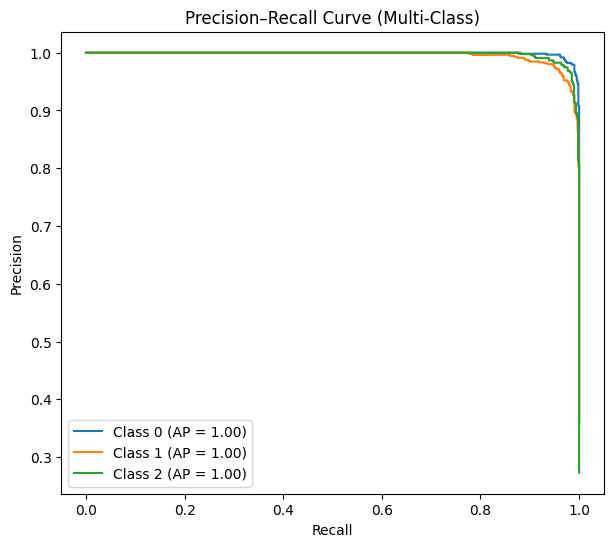

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for i in range(len(cm)):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i],
                                                  [p[i] for p in all_probs])
    ap = average_precision_score(all_labels_bin[:, i],
                                 [p[i] for p in all_probs])
    plt.plot(recall, precision, label=f"Class {i} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Multi-Class)")
plt.legend()
plt.show()

In [ ]:

all_preds_np  = np.array(all_preds)
all_labels_np = np.array(all_labels)
all_probs_np  = np.array(all_probs)

eval_results = {
    "preds": all_preds_np,
    "labels": all_labels_np,
    "probs": all_probs_np,

    "confusion_matrix": confusion_matrix(all_labels_np, all_preds_np),
    "classification_report": classification_report(all_labels_np, all_preds_np, output_dict=True),


    "accuracy": float((all_preds_np == all_labels_np).sum() / len(all_labels_np)),
}

### Train One Epoch - Run Before Running Transfer Models

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

### VGG 11 

In [ ]:
num_classes = len(train_dataset.classes)

model = models.vgg11(weights=models.VGG11_Weights.IMAGENET1K_V1)

# Replace classifier head
model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=num_classes
)

model = model.to(DEVICE)

In [ ]:
# Freeze ALL convolutional layers
for param in model.features.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),  # only head
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3,
)

prev_lr = optimizer.param_groups[0]["lr"]

In [ ]:
best_val_loss = float("inf")
patience, counter = 5, 0
num_epochs_stage1 = 15

for epoch in range(num_epochs_stage1):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    scheduler.step(val_loss)

    curr_lr = optimizer.param_groups[0]["lr"]
    if curr_lr != prev_lr:
        print(f"🔻 LR reduced: {prev_lr:.2e} → {curr_lr:.2e}")
        prev_lr = curr_lr

    print(f"[Stage 1][Epoch {epoch+1}/{num_epochs_stage1}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "vgg11_stage1_best.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (Stage 1)")
            break

[Stage 1][Epoch 1/15] Train Loss: 0.5393 | Train Acc: 0.7992 Val Loss: 0.3093 | Val Acc: 0.8915
[Stage 1][Epoch 2/15] Train Loss: 0.2375 | Train Acc: 0.9126 Val Loss: 0.3928 | Val Acc: 0.8609
[Stage 1][Epoch 3/15] Train Loss: 0.1651 | Train Acc: 0.9372 Val Loss: 0.3927 | Val Acc: 0.8782
[Stage 1][Epoch 4/15] Train Loss: 0.1216 | Train Acc: 0.9572 Val Loss: 0.4182 | Val Acc: 0.8805
🔻 LR reduced: 1.00e-03 → 3.00e-04
[Stage 1][Epoch 5/15] Train Loss: 0.0963 | Train Acc: 0.9670 Val Loss: 0.6671 | Val Acc: 0.8632
[Stage 1][Epoch 6/15] Train Loss: 0.0459 | Train Acc: 0.9831 Val Loss: 0.4338 | Val Acc: 0.8909
Early stopping (Stage 1)


In [ ]:
# Unfreeze last two convolution blocks
for layer in model.features[-8:]:
    for param in layer.parameters():
        param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
best_val_loss = float("inf")
counter = 0
num_epochs_stage2 = 25

for epoch in range(num_epochs_stage2):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    print(f"[Stage 2][Epoch {epoch+1}/{num_epochs_stage2}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "vgg11_best.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (Stage 2)")
            break


[Stage 2][Epoch 1/25] Train Loss: 0.1215 | Train Acc: 0.9667 Val Loss: 0.3176 | Val Acc: 0.9094
[Stage 2][Epoch 2/25] Train Loss: 0.0265 | Train Acc: 0.9910 Val Loss: 0.5890 | Val Acc: 0.8880
[Stage 2][Epoch 3/25] Train Loss: 0.0253 | Train Acc: 0.9907 Val Loss: 0.4312 | Val Acc: 0.9088
[Stage 2][Epoch 4/25] Train Loss: 0.0386 | Train Acc: 0.9876 Val Loss: 0.3394 | Val Acc: 0.8932
[Stage 2][Epoch 5/25] Train Loss: 0.0188 | Train Acc: 0.9931 Val Loss: 0.4146 | Val Acc: 0.9007
[Stage 2][Epoch 6/25] Train Loss: 0.0144 | Train Acc: 0.9944 Val Loss: 0.3925 | Val Acc: 0.9105
Early stopping (Stage 2)


In [ ]:
train_history = {
    "model": "VGG11",
    "seed": SEED,
    "stage1": {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    },
    "stage2": {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    },
    "best_epoch": None,
    "best_val_loss": None
}

In [ ]:
train_history["stage1"]["train_loss"].append(train_loss)
train_history["stage1"]["val_loss"].append(val_loss)
train_history["stage1"]["train_acc"].append(train_acc)
train_history["stage1"]["val_acc"].append(val_acc)


In [ ]:
train_history["stage2"]["train_loss"].append(train_loss)
train_history["stage2"]["val_loss"].append(val_loss)
train_history["stage2"]["train_acc"].append(train_acc)
train_history["stage2"]["val_acc"].append(val_acc)


In [ ]:
train_history["best_epoch"] = epoch
train_history["best_val_loss"] = best_val_loss


In [ ]:
save_path = "/content/drive/MyDrive/TransferLearning/vgg11_train_history.pth"

torch.save(train_history, save_path)
print("Saved VGG-11 training history ✓")


Saved VGG-11 training history ✓


In [ ]:
history = torch.load(save_path, weights_only=False)


In [ ]:
model.load_state_dict(torch.load("vgg11_best.pth"))

test_loss, test_acc = eval_one_epoch(
    model, testloader, criterion
)

print(f"✅ VGG-11 Test Accuracy: {test_acc:.4f}")


✅ VGG-11 Test Accuracy: 0.9055


In [ ]:
def evaluate_and_collect(model, loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probabilities, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probabilities.cpu())

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = torch.cat(all_probs).numpy()

    cm = confusion_matrix(labels, preds)
    report = classification_report(
        labels, preds, target_names=class_names, output_dict=True
    )
    acc = accuracy_score(labels, preds)

    results = {
        "preds": preds,
        "labels": labels,
        "probs": probs,
        "confusion_matrix": cm,
        "classification_report": report,
        "accuracy": acc,
        "class_names": class_names
    }

    return results


In [ ]:
model.load_state_dict(torch.load("vgg11_best.pth"))
model.to(DEVICE)

eval_results = evaluate_and_collect(
    model,
    testloader,
    class_names=train_dataset.classes
)

In [ ]:
save_path = "/content/drive/MyDrive/TransferLearning/vgg11_eval_results.pth"

torch.save(eval_results, save_path)
print("Saved VGG-11 evaluation results ✓")

Saved VGG-11 evaluation results ✓


In [ ]:
eval_results = torch.load(
    "/content/drive/MyDrive/TransferLearning/vgg11_eval_results.pth",
    weights_only=False
)

preds  = eval_results["preds"]
labels = eval_results["labels"]
probs  = eval_results["probs"]
cm     = eval_results["confusion_matrix"]
report = eval_results["classification_report"]
acc    = eval_results["accuracy"]

### ResNet-18

In [ ]:
num_classes = len(train_dataset.classes)

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(DEVICE)

In [ ]:

for param in model.parameters():
    param.requires_grad = False


for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),   # head only
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3
)

prev_lr = optimizer.param_groups[0]["lr"]

In [ ]:
best_val_loss = float("inf")
patience, counter = 5, 0
num_epochs_stage1 = 15

for epoch in range(num_epochs_stage1):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    scheduler.step(val_loss)

    curr_lr = optimizer.param_groups[0]["lr"]
    if curr_lr != prev_lr:
        print(f"🔻 LR reduced: {prev_lr:.2e} → {curr_lr:.2e}")
        prev_lr = curr_lr

    print(f"[ResNet-18 | Stage 1 | Epoch {epoch+1}/{num_epochs_stage1}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/TransferLearning/resnet18_stage1_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (ResNet-18 Stage 1)")
            break

[ResNet-18 | Stage 1 | Epoch 1/15] Train Acc: 0.8560 | Val Acc: 0.8724
[ResNet-18 | Stage 1 | Epoch 2/15] Train Acc: 0.8739 | Val Acc: 0.8782
[ResNet-18 | Stage 1 | Epoch 3/15] Train Acc: 0.8839 | Val Acc: 0.8897
[ResNet-18 | Stage 1 | Epoch 4/15] Train Acc: 0.8839 | Val Acc: 0.8909
[ResNet-18 | Stage 1 | Epoch 5/15] Train Acc: 0.8870 | Val Acc: 0.8915
[ResNet-18 | Stage 1 | Epoch 6/15] Train Acc: 0.8909 | Val Acc: 0.8926
[ResNet-18 | Stage 1 | Epoch 7/15] Train Acc: 0.8909 | Val Acc: 0.8915
[ResNet-18 | Stage 1 | Epoch 8/15] Train Acc: 0.8959 | Val Acc: 0.8938
[ResNet-18 | Stage 1 | Epoch 9/15] Train Acc: 0.8996 | Val Acc: 0.8932
[ResNet-18 | Stage 1 | Epoch 10/15] Train Acc: 0.8914 | Val Acc: 0.8926
[ResNet-18 | Stage 1 | Epoch 11/15] Train Acc: 0.8898 | Val Acc: 0.8932
[ResNet-18 | Stage 1 | Epoch 12/15] Train Acc: 0.9002 | Val Acc: 0.8961
[ResNet-18 | Stage 1 | Epoch 13/15] Train Acc: 0.8980 | Val Acc: 0.8851
[ResNet-18 | Stage 1 | Epoch 14/15] Train Acc: 0.8913 | Val Acc: 0.8972
[

In [ ]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
best_val_loss = float("inf")
counter = 0
num_epochs_stage2 = 25

for epoch in range(num_epochs_stage2):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    print(f"[ResNet-18 | Stage 2 | Epoch {epoch+1}/{num_epochs_stage2}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/TransferLearning/resnet18_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (ResNet-18 Stage 2)")
            break


[ResNet-18 | Stage 2 | Epoch 1/25] Train Acc: 0.9153 | Val Acc: 0.9296
[ResNet-18 | Stage 2 | Epoch 2/25] Train Acc: 0.9868 | Val Acc: 0.9371
[ResNet-18 | Stage 2 | Epoch 3/25] Train Acc: 0.9975 | Val Acc: 0.9411
[ResNet-18 | Stage 2 | Epoch 4/25] Train Acc: 0.9990 | Val Acc: 0.9428
[ResNet-18 | Stage 2 | Epoch 5/25] Train Acc: 0.9995 | Val Acc: 0.9423
[ResNet-18 | Stage 2 | Epoch 6/25] Train Acc: 0.9984 | Val Acc: 0.9336
[ResNet-18 | Stage 2 | Epoch 7/25] Train Acc: 0.9998 | Val Acc: 0.9388
[ResNet-18 | Stage 2 | Epoch 8/25] Train Acc: 0.9986 | Val Acc: 0.9434
Early stopping (ResNet-18 Stage 2)


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/TransferLearning/resnet18_best.pth")
)

test_loss, test_acc = eval_one_epoch(
    model, testloader, criterion
)

print(f"✅ ResNet-18 Test Accuracy: {test_acc:.4f}")


✅ ResNet-18 Test Accuracy: 0.9459


In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(DEVICE)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels)

all_probs  = torch.cat(all_probs).numpy()
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}


In [ ]:
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)
history["lr"].append(optimizer.param_groups[0]["lr"])

In [ ]:
torch.save(
    history,
    "/content/drive/MyDrive/TransferLearning/resnet18_history.pth"
)

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(
    all_labels, all_preds, target_names=test_dataset.classes
)
acc = accuracy_score(all_labels, all_preds)

In [ ]:
eval_results = {
    "model": "resnet18",
    "preds": all_preds,
    "labels": all_labels,
    "probs": all_probs,
    "confusion_matrix": cm,
    "classification_report": report,
    "accuracy": acc
}

torch.save(
    eval_results,
    "/content/drive/MyDrive/TransferLearning/resnet18_eval_results.pth"
)

print("✅ ResNet-18 evaluation saved")

✅ ResNet-18 evaluation saved


In [ ]:
eval_results = torch.load(
    "/content/drive/MyDrive/TransferLearning/resnet18_eval_results.pth",
    weights_only=False
)

print("Accuracy:", eval_results["accuracy"])
print(eval_results["classification_report"])


Accuracy: 0.945852534562212
              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98       623
         MLB       0.93      0.94      0.93       639
        Soil       0.94      0.90      0.92       474

    accuracy                           0.95      1736
   macro avg       0.95      0.94      0.94      1736
weighted avg       0.95      0.95      0.95      1736



### MobileNetV2

In [ ]:
num_classes = len(train_dataset.classes)

model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 131MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3
)

prev_lr = optimizer.param_groups[0]["lr"]

In [ ]:
best_val_loss = float("inf")
patience, counter = 5, 0
num_epochs_stage1 = 10

for epoch in range(num_epochs_stage1):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    scheduler.step(val_loss)

    curr_lr = optimizer.param_groups[0]["lr"]
    if curr_lr != prev_lr:
        print(f"🔻 LR reduced: {prev_lr:.2e} → {curr_lr:.2e}")
        prev_lr = curr_lr

    print(f"[MobileNetV2 | Stage 1 | Epoch {epoch+1}/{num_epochs_stage1}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/TransferLearning/mobilenetv2_stage1_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (MobileNet Stage 1)")
            break


[MobileNetV2 | Stage 1 | Epoch 1/10] Train Acc: 0.8741 | Val Acc: 0.8753
[MobileNetV2 | Stage 1 | Epoch 2/10] Train Acc: 0.8791 | Val Acc: 0.9007
[MobileNetV2 | Stage 1 | Epoch 3/10] Train Acc: 0.8858 | Val Acc: 0.9076
[MobileNetV2 | Stage 1 | Epoch 4/10] Train Acc: 0.8860 | Val Acc: 0.9076
[MobileNetV2 | Stage 1 | Epoch 5/10] Train Acc: 0.8923 | Val Acc: 0.9099
[MobileNetV2 | Stage 1 | Epoch 6/10] Train Acc: 0.8896 | Val Acc: 0.9082
[MobileNetV2 | Stage 1 | Epoch 7/10] Train Acc: 0.8956 | Val Acc: 0.9111
[MobileNetV2 | Stage 1 | Epoch 8/10] Train Acc: 0.8966 | Val Acc: 0.9105
[MobileNetV2 | Stage 1 | Epoch 9/10] Train Acc: 0.8968 | Val Acc: 0.9134
[MobileNetV2 | Stage 1 | Epoch 10/10] Train Acc: 0.8933 | Val Acc: 0.9065


In [ ]:
for param in model.features[-2:].parameters():
    param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
best_val_loss = float("inf")
counter = 0
num_epochs_stage2 = 20

for epoch in range(num_epochs_stage2):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    print(f"[MobileNetV2 | Stage 2 | Epoch {epoch+1}/{num_epochs_stage2}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/TransferLearning/mobilenetv2_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (MobileNet Stage 2)")
            break


[MobileNetV2 | Stage 2 | Epoch 1/20] Train Acc: 0.9047 | Val Acc: 0.9221
[MobileNetV2 | Stage 2 | Epoch 2/20] Train Acc: 0.9332 | Val Acc: 0.9475
[MobileNetV2 | Stage 2 | Epoch 3/20] Train Acc: 0.9471 | Val Acc: 0.9486
[MobileNetV2 | Stage 2 | Epoch 4/20] Train Acc: 0.9576 | Val Acc: 0.9509
[MobileNetV2 | Stage 2 | Epoch 5/20] Train Acc: 0.9591 | Val Acc: 0.9463
[MobileNetV2 | Stage 2 | Epoch 6/20] Train Acc: 0.9681 | Val Acc: 0.9469
[MobileNetV2 | Stage 2 | Epoch 7/20] Train Acc: 0.9749 | Val Acc: 0.9446
[MobileNetV2 | Stage 2 | Epoch 8/20] Train Acc: 0.9800 | Val Acc: 0.9359
[MobileNetV2 | Stage 2 | Epoch 9/20] Train Acc: 0.9813 | Val Acc: 0.9452
[MobileNetV2 | Stage 2 | Epoch 10/20] Train Acc: 0.9859 | Val Acc: 0.9475
[MobileNetV2 | Stage 2 | Epoch 11/20] Train Acc: 0.9845 | Val Acc: 0.9348
Early stopping (MobileNet Stage 2)


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}


In [ ]:
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)
history["lr"].append(optimizer.param_groups[0]["lr"])

In [ ]:
torch.save(
    history,
    "/content/drive/MyDrive/TransferLearning/mobilenetv2_history.pth"
)

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/TransferLearning/mobilenetv2_best.pth"
    )
)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_probs  = torch.cat(all_probs).numpy()
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

report = classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
)

acc = accuracy_score(all_labels, all_preds)

In [ ]:
eval_results = {
    "model": "mobilenetv2",
    "preds": all_preds,
    "labels": all_labels,
    "probs": all_probs,
    "confusion_matrix": cm,
    "classification_report": report,
    "accuracy": acc
}

torch.save(
    eval_results,
    "/content/drive/MyDrive/TransferLearning/mobilenetv2_eval_results.pth"
)


In [ ]:
eval_results = torch.load(
    "/content/drive/MyDrive/TransferLearning/mobilenetv2_eval_results.pth",
    weights_only=False
)

print("Accuracy:", eval_results["accuracy"])
print(eval_results["classification_report"])

Accuracy: 0.9481566820276498
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97       623
         MLB       0.93      0.94      0.94       639
        Soil       0.93      0.93      0.93       474

    accuracy                           0.95      1736
   macro avg       0.95      0.95      0.95      1736
weighted avg       0.95      0.95      0.95      1736



### EfficientNet-B0

In [ ]:
num_classes = len(train_dataset.classes)

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(DEVICE)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3
)

prev_lr = optimizer.param_groups[0]["lr"]

In [ ]:
best_val_loss = float("inf")
patience, counter = 5, 0
num_epochs_stage1 = 10

for epoch in range(num_epochs_stage1):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    scheduler.step(val_loss)

    curr_lr = optimizer.param_groups[0]["lr"]
    if curr_lr != prev_lr:
        print(f"🔻 LR reduced: {prev_lr:.2e} → {curr_lr:.2e}")
        prev_lr = curr_lr

    print(f"[EffNet-B0 | Stage 1 | Epoch {epoch+1}/{num_epochs_stage1}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/TransferLearning/efficientnetb0_stage1_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (EffNet-B0 Stage 1)")
            break


In [ ]:
for param in model.features[-2:].parameters():
    param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
best_val_loss = float("inf")
counter = 0
num_epochs_stage2 = 20

for epoch in range(num_epochs_stage2):
    train_loss, train_acc = train_one_epoch(
        model, trainloader, optimizer, criterion
    )

    val_loss, val_acc = eval_one_epoch(
        model, valloader, criterion
    )

    print(f"[EffNet-B0 | Stage 2 | Epoch {epoch+1}/{num_epochs_stage2}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "/content/TransferLearning/efficientnetb0_best.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping (EffNet-B0 Stage 2)")
            break


In [ ]:
eval_results = {
    "model": "efficientnet_b0",
    "preds": all_preds,
    "labels": all_labels,
    "probs": all_probs,
    "confusion_matrix": cm,
    "classification_report": report,
    "accuracy": acc
}

torch.save(
    eval_results,
    "/content/TransferLearning/efficientnetb0_eval_results.pth"
)

print("✅ EfficientNet-B0 evaluation saved")
